$$
\text{非线性回归模型 (Non-Linear Regression Model)} \\ \quad \\
\text{首先先确定模型, 观察散点图}
$$

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

times = np.arange(1, 17)
volumes = np.array([
    np.nan, 6.42, 8.20, 9.58, 9.50, 9.70, 10.00, 9.93, 
    9.99, 10.49, 10.59, 10.60, 10.80, 10.60, 10.90, 10.76
])

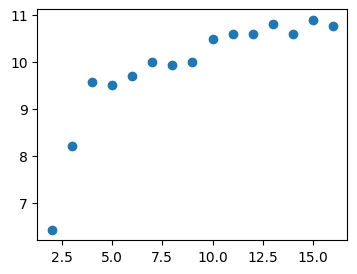

In [18]:
plt.figure(figsize=(4, 3))
plt.scatter(times, volumes)

$$
\text{根据散点图, 可以确定模型为} \\ \quad \\
y = ae^{\frac{b}{x}} \\ \quad \\
\text{取对数} \\ \quad \\
\ln y = \ln a + \frac{b}{x} \ln e = \ln a + \frac{b}{x} \\ \quad \\
\text{令 } \hat{y} = \ln y,  x' = \frac{1}{x}, \hat{b} = \ln a, \hat{A} = b \\ \quad \\
\text{则模型为} \\ \quad \\
\hat{y} = \hat{b} + \hat{A} x' \\ \quad \\
\text{接着求线性回归模型}
$$

In [ ]:
hat_y = np.log(volumes[1:])
prime_x = 1 / times[1:]
n = volumes.size - 1
sum_xy = (hat_y * prime_x).sum()
sum_x = prime_x.sum()
sum_y = hat_y.sum()
sum_x2 = (prime_x ** 2).sum()
x_bar = sum_x / n
y_bar = sum_y / n

hat_A = (n * sum_xy - sum_y * sum_x) / (n * sum_x2 - sum_x ** 2)
hat_b = y_bar - hat_A * x_bar
a = np.exp(hat_b)
print(f'hat_A = {hat_A}')
print(f'hat_b = {hat_b}')
print(f'a = {a}')

hat_A = -1.1106713597786577
hat_b = 2.457784685487524
a = 11.678910401287496


$$
\text{所以回归模型为} \\ \quad \\
\textbf{y = } 11.67891 e^{\frac{-1.11067}{x}} \\ \quad \\
$$

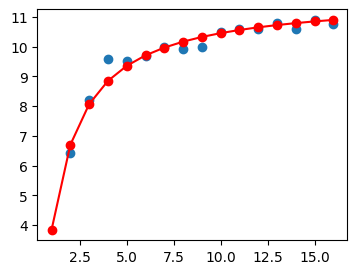

In [23]:
plt.figure(figsize=(4, 3))
plt.scatter(times, volumes)
plt.plot(times, a * np.exp(hat_A / times), color='red', marker='o')

$$
\text{常见的六类曲线} \\ \quad \\
\text{双曲线 (Hyperbola)} \\ \quad \\
\left\{
\begin{array}{l}
\hat{y} = \frac{x}{a + bx} \\
\hat{y} = \frac{a + bx}{x} \\
\hat{y} = \frac{1}{a + bx} \\
\end{array}
\right\}
$$

$$
\hat{y} = \frac{x}{a + bx} \\
\text{两边去倒数} \implies \frac{1}{\hat{y}} = \frac{a + bx}{x} \\
\text{两边同时乘以 x} \implies \frac{x}{\hat{y}} = a + bx \\
\text{令 } y' = \frac{x}{\hat{y}}, A = a, B = b \\
y' = A + Bx
$$

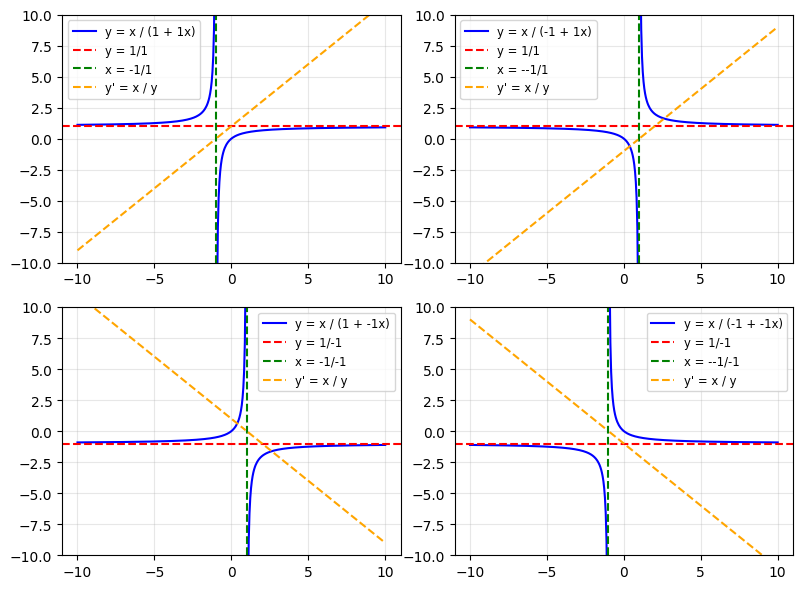

In [119]:
import numpy as np
import matplotlib.pyplot as plt

def get_y(a, b, x):
    # 使用 np.where 避免除零警告
    denom = a + b * x
    return np.divide(x, denom, out=np.zeros_like(x), where=denom!=0)

a_list, b_list = [1, -1, 1, -1], [1, 1, -1, -1]
x = np.linspace(-10, 10, 400) # 减小范围并增加采样点以获得更平滑的曲线

fig, axs = plt.subplots(2, 2, figsize=(8, 6))
for i in range(4):
    a, b = a_list[i], b_list[i]
    y = get_y(a, b, x)
    ax = axs[i // 2, i % 2]
    
    # 绘制主曲线（处理断点避免连线）
    y[np.abs(y) > 20] = np.nan 
    ax.plot(x, y, label=f'y = x / ({a} + {b}x)', color='blue')
    
    # 水平渐近线: y = 1/b
    ax.axhline(y=1/b, color='r', linestyle='--', label=f'y = 1/{b}')
    
    # 垂直渐近线: x = -a/b
    ax.axvline(x=-a/b, color='g', linestyle='--', label=f'x = -{a}/{b}')
    
    ax.plot(x, x / y, color='orange', linestyle='--', label=f'y\' = x / y')
    
    ax.set_ylim(-10, 10)
    ax.legend(fontsize='small')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

$$
\hat{y} = \frac{a + bx}{x} \\
\text{两边同时乘以 x} \implies \hat{y}x = a + bx \\
\text{令 } y' = \hat{y}x, A = a, B = b \\
y' = A + Bx
$$

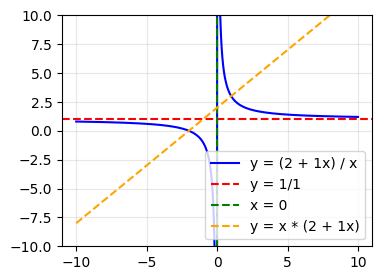

In [121]:
a, b = 2, 1
x = np.linspace(-10, 10, 400)
y = (a + b * x) / x

plt.figure(figsize=(4, 3))
plt.plot(x, y, label=f'y = ({a} + {b}x) / x', color='blue')
plt.axhline(y=1/b, color='r', linestyle='--', label=f'y = 1/{b}')    
plt.axvline(x=0, color='g', linestyle='--', label=f'x = 0')

plt.plot(x, x * y, color='orange', linestyle='--', label=f'y = x * ({a} + {b}x)')

plt.legend(fontsize='small')
plt.grid(True, alpha=0.3)
plt.ylim(-10, 10)
plt.legend()
plt.show()

$$
\text{双倒数变换 (林贝方程 Lineweaver-Burke plot)} \\
\hat{y} = \frac{1}{a + bx} \\
\text{两边去倒数 } \implies \frac{1}{\hat{y}} = a + bx \\
\text{令 } y' = \frac{1}{\hat{y}}, A = a, B = b \\
y' = A + Bx \\
$$

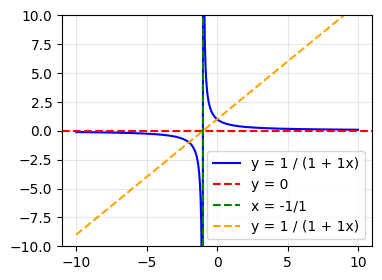

In [124]:
a, b = 1, 1
x = np.linspace(-10, 10, 400)
y = 1 / (a + b * x)

plt.figure(figsize=(4, 3))
plt.plot(x, y, label=f'y = 1 / ({a} + {b}x)', color='blue')
plt.axhline(y=0, color='r', linestyle='--', label='y = 0')    
plt.axvline(x=-a/b, color='g', linestyle='--', label=f'x = -{a}/{b}')
plt.plot(x, 1 / y, color='orange', linestyle='--', label=f'y = 1 / ({a} + {b}x)')
plt.legend(fontsize='small')
plt.grid(True, alpha=0.3)
plt.ylim(-10, 10)
plt.legend()
plt.show()

$$
\text{幂函数曲线 (Power Function)} \\
\hat{y} = a x^b \\
\text{两边取对数} \implies \ln(\hat{y}) = \ln(a + x^b) = \ln(a) + \ln(x^b) = \ln(a) + b \ln(x) \\
\text{令 } y' = \ln(\hat{y}), A = \ln(a), B = b,  x' = \ln(x) \\
y' = A + B x' \\
$$

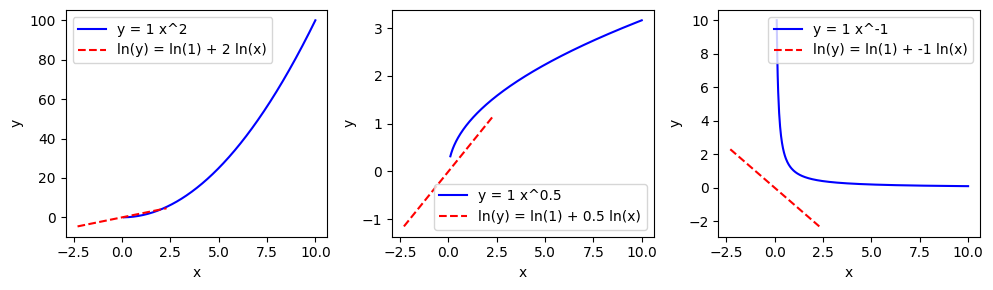

In [171]:
from matplotlib.pyplot import spy
def get_y(a, b, x):
    return a * x**b

a, b = [1, 1, 1], [2, 0.5, -1]
x = np.linspace(0.1, 10, 400)

fig, axs = plt.subplots(1, 3, figsize=(10, 3))
for i in range(len(a)):
    y = get_y(a[i], b[i], x)
    
    ax = axs[i]
    ax.plot(x, y, label=f'y = {a[i]} x^{b[i]}', color='b')
    ax.plot(np.log(x), np.log(y), label=f'ln(y) = ln({a[i]}) + {b[i]} ln(x)', color='r', linestyle='--', markersize=4)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Linearized: ln(y) = ln(2) + 1.5*ln(x)')

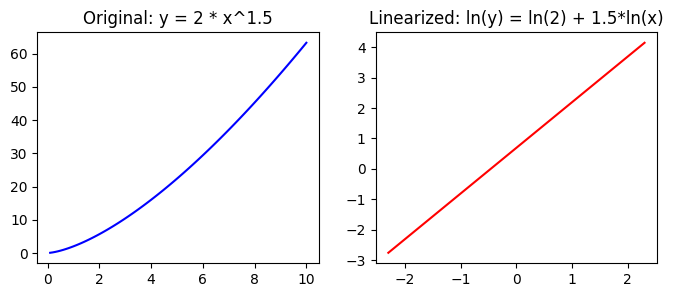

In [174]:
x = np.linspace(0.1, 10, 100)
y = 2 * x**1.5  # 幂函数

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# 1. 原始空间：曲线
ax1.plot(x, y, 'b')
ax1.set_title("Original: y = 2 * x^1.5")

# 2. 对数空间：直线 (Linearized)
# 注意：横纵坐标都取对数
ax2.plot(np.log(x), np.log(y), 'r')
ax2.set_title("Linearized: ln(y) = ln(2) + 1.5*ln(x)")

$$
\text{指数函数曲线} \\
\left\{ \begin{array}{ll}
\hat{y} = ae^{bx} \\
\hat{y} = ab^x \\
\end{array}
\right\}
$$